In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
V0 = 1e-10
v0 = V0 / 24 * np.pi * np.pi
beta = 0.01
deltaPhiWell = 2 * (2 / 3 * v0 / beta) ** (1 / 3)
phi0 = 0.5 * deltaPhiWell + 0.3 / np.sqrt(beta)

def infPotFunc(phi):
    x = phi - phi0
    return float(V0 * (1 + beta * x * x * x))

def infPotDerivFunc(phi):
    x = phi - phi0
    return float(3 * V0 * beta * x * x)

def infPotDeriv2Func(phi):
    x = phi - phi0
    return float(6 * V0 * beta * x)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

upperBound = phi0 + beta ** (-1 / 3)
lowerBound = phi0 - 0.9 * beta ** (-1 / 3)

nGrid = 400
customGridLeft = phi0 - np.exp(np.linspace(np.log(phi0 - lowerBound), np.log(deltaPhiWell), int(nGrid / 4), endpoint=False))
customGridMid = np.linspace(phi0 - deltaPhiWell, phi0 + deltaPhiWell, int(nGrid / 2), endpoint=False)
customGridRight = phi0 + np.exp(np.linspace(np.log(deltaPhiWell), np.log(upperBound - phi0), int(nGrid / 4), endpoint=False))
customGrid = np.concatenate([customGridLeft, customGridMid, customGridRight])    

In [3]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"],
    customGrid=[customGrid]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

c:\Users\koich\Desktop\Code\StochasticInflationDiffOpEigen\InfAdjFPFiniteDiffApp.py:116: RuntimeWarning: invalid value encountered in double_scalars
  slowrollEta = np.abs(vDers.T @ vDer2AtGrids[:,:,ig] @ vDers / vAtGrids[ig] / np.sum(vDers ** 2))


In [4]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

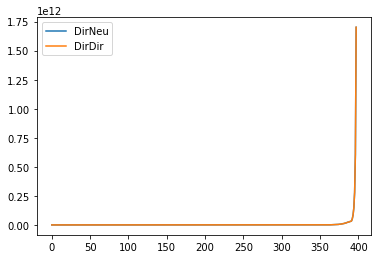

In [5]:
nMode = np.arange(nGrid - 2)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

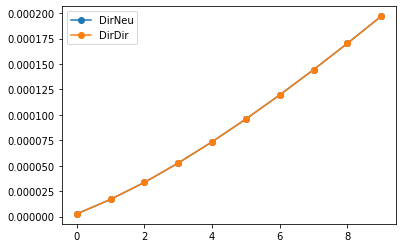

In [6]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [7]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[2.55767268e-06 1.68881537e-05 3.35247480e-05 5.25633535e-05
 7.34342306e-05 9.58251172e-05 1.19516279e-04 1.44342966e-04
 1.70175311e-04 1.96907208e-04]
[2.55767268e-06 1.68881537e-05 3.35247480e-05 5.25633535e-05
 7.34342306e-05 9.58251172e-05 1.19516279e-04 1.44342966e-04
 1.70175311e-04 1.96907208e-04]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

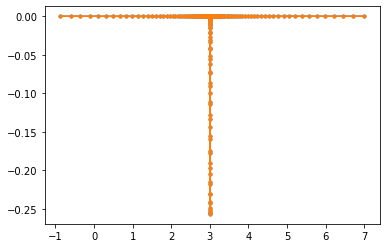

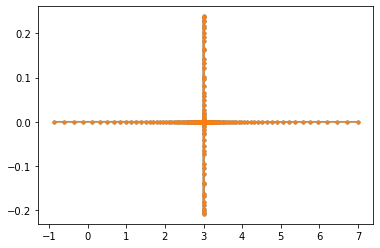

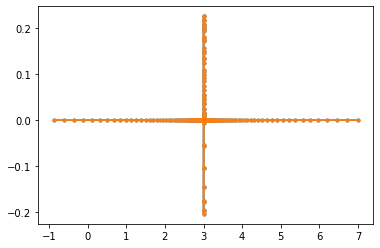

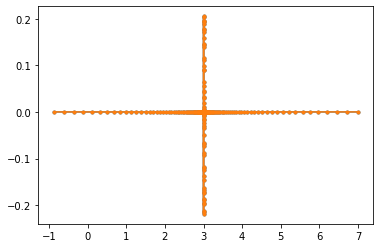

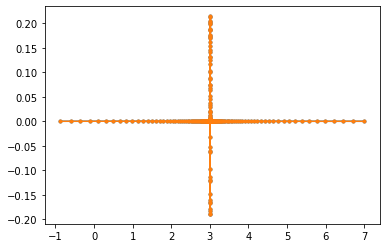

In [11]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid[1:-1], eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(customGrid[1:-1], eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

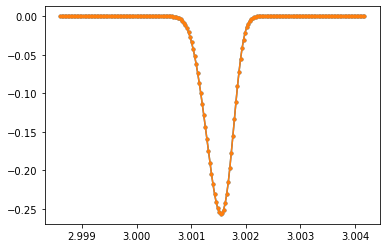

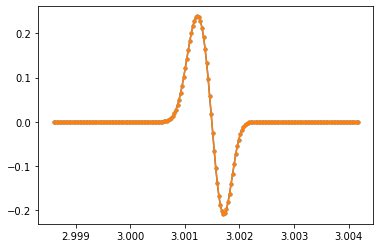

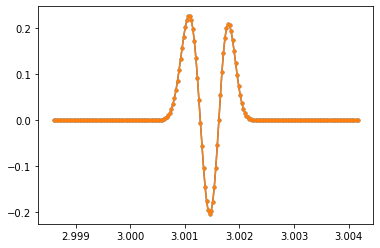

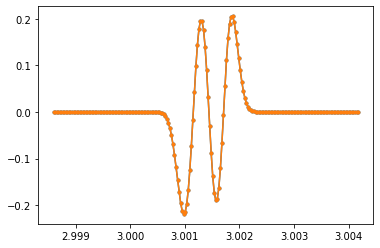

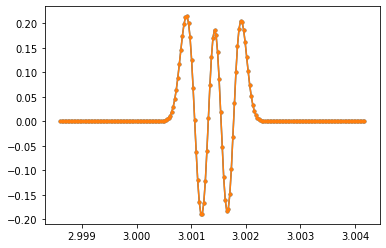

In [15]:
# 固有関数のプロット（phi0近傍）
ax = plt.gca()
idAroundPhi0 = np.arange((int)(nGrid / 4),(int)(3 * nGrid / 4))

for iEig in range(5):
    plt.plot(customGrid[idAroundPhi0], eigVecsSort_DirNeu[iEig][idAroundPhi0],marker='.', label="DirNeu")
    plt.plot(customGrid[idAroundPhi0], eigVecsSort_DirDir[iEig][idAroundPhi0],marker='.', label="DirDir")
    plt.show()

wellをちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [19]:
sigma = deltaPhiWell / 6.0
trialVec = np.exp(- 0.5 * ((customGrid[1:-1] - phi0) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

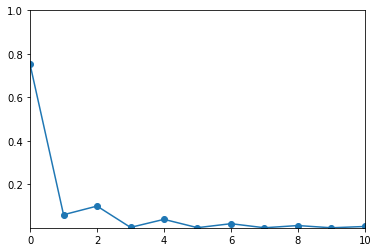

In [22]:
# 各固有ベクトルの寄与度
contriEachEigVec = []
trialVecNorm = np.sum([trialVec[i] * trialVec[i] * (customGrid[i+1] - customGrid[i]) for i in range(1, nGrid - 2)])
for ev in eigVecsSort_DirDir:
    integ = np.sum([ev[i] * trialVec[i] * (customGrid[i+1] - customGrid[i]) for i in range(1, nGrid - 2)])
    evNorm = np.sum([ev[i] * ev[i] * (customGrid[i+1] - customGrid[i]) for i in range(1, nGrid - 2)])
    contriEachEigVec.append(integ ** 2 / evNorm / trialVecNorm)

ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

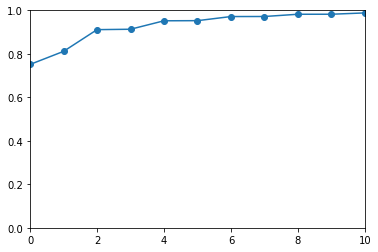

In [23]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()